# Microfinance Fraud Detection using Machine Learning

## Feature Engineering

### Objective

The objective of this notebook is to improve the predictive performance of machine learning models by creating informative features, selecting relevant variables, and removing unnecessary attributes.

### Tasks

- Load cleaned dataset
- Create derived features
- Encode engineered features
- Remove low-variance features
- Feature importance analysis
- Select final features

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:\\Users\\Dinesh\\OneDrive\\Desktop\\Microfinance-Fraud-Detection\\data\\raw\\microfinance_fraud_detection_dataset.csv')
df.head()


,transaction_id,customer_id,branch_id,loan_id,customer_age,gender,marital_status,education_level,occupation,annual_income,...,income_stability_score,employment_tenure_years,credit_utilization_ratio,active_loans_count,total_debt_obligation,financial_dependency_ratio,savings_balance,penalty_charges,fraud_type,is_fraud
0,TXN000001,CUST01825,BR049,LOAN04822,43,Male,Divorced,Diploma,Retired,45591.89,...,0.7108,25.09,0.3091,1,70864.38,1.5543,366.27,2.69,Not Fraud,0
1,TXN000002,CUST00410,BR174,LOAN05235,36,Male,Married,Primary,Farmer,75316.77,...,0.5664,2.49,0.0835,2,76609.22,1.0172,3837.05,0.00,Not Fraud,0
2,TXN000003,CUST04507,BR163,LOAN07508,45,Female,Married,PhD,Small Business Owner,53905.76,...,0.7840,2.72,0.6358,1,97220.41,1.8035,698.63,0.00,Not Fraud,0
3,TXN000004,CUST04013,BR158,LOAN12869,56,Female,Single,Secondary,Self-Employed,34222.08,...,0.6262,12.82,0.2256,4,36526.56,1.0673,2177.94,0.00,Not Fraud,0
4,TXN000005,CUST03658,BR021,LOAN06457,35,Male,Divorced,Secondary,Salaried Employee,89250.89,...,0.8419,14.37,1.0249,2,150323.27,1.6843,13883.37,0.00,Not Fraud,0


In [3]:
drop_columns = [
    "customer_id",
    "loan_id",
    "transaction_id",
    "fraud_type"
]

df.drop(columns=drop_columns, inplace=True, errors="ignore")

In [4]:
df["loan_income_percent"] = (
    df["requested_amount"] / df["annual_income"]
) * 100

In [5]:
df["credit_risk_index"] = (
    850 - df["credit_score"]
)

In [6]:
df["digital_risk_score"] = (
    df["network_risk_score"] +
    df["suspicious_transaction_count"] +
    df["aml_alert_count"]
)

In [7]:
df["verification_risk"] = (
    df["identity_verification_failed"].astype(int) +
    df["blacklist_match"].astype(int) +
    df["duplicate_application"].astype(int)
)

In [9]:
X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]

In [10]:
categorical_columns = X.select_dtypes(include="object").columns

encoder = LabelEncoder()

for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col].astype(str))

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_30688\1739219826.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [11]:
selector = VarianceThreshold(threshold=0.01)

X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

X = pd.DataFrame(
    X_selected,
    columns=selected_columns
)

In [12]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [17]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})
importances.sort_values(by="importance", ascending=False, inplace=True)

importances.head(10)

,feature,importance
62,kyc_completeness,0.024479
63,document_verification_score,0.022167
83,credit_utilization_ratio,0.020028
29,processing_time_days,0.019199
50,unusual_transaction_ratio,0.019175
72,network_risk_score,0.018688
78,application_date,0.018114
76,days_since_disbursement,0.018042
46,transaction_velocity,0.017742
73,typing_speed_anomaly,0.017625


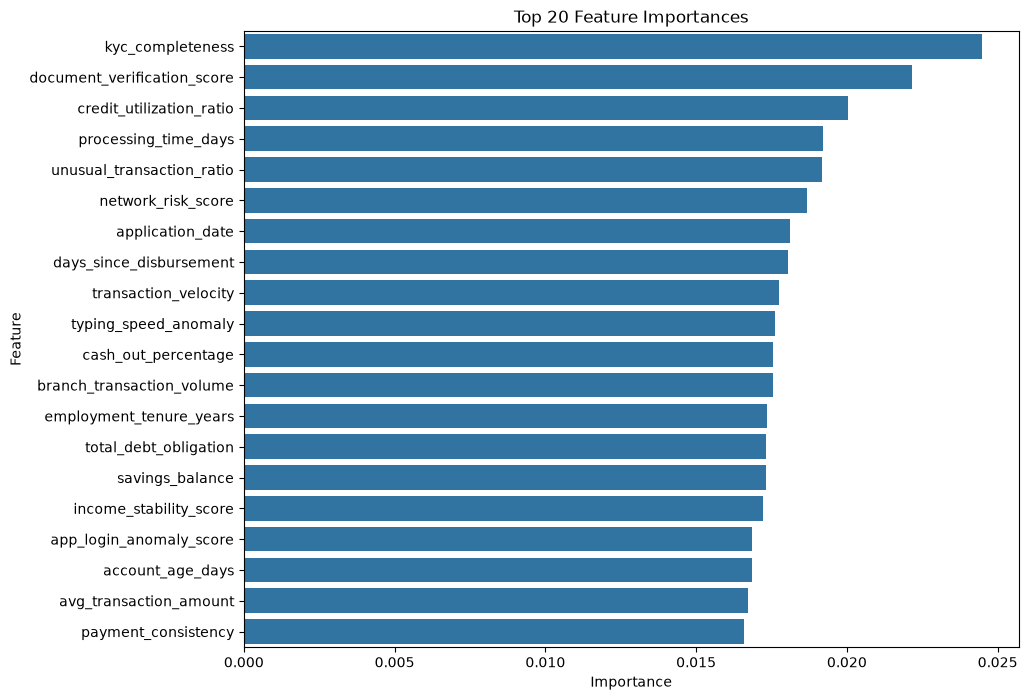

In [18]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x="importance",
    y="feature",
    data=importances.head(20)
)
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [19]:
top_features = importances.head(30)["feature"].tolist()

X = X[top_features]

X.head()


,kyc_completeness,document_verification_score,credit_utilization_ratio,processing_time_days,unusual_transaction_ratio,network_risk_score,application_date,days_since_disbursement,transaction_velocity,typing_speed_anomaly,...,total_transaction_volume,distance_to_branch_km,click_pattern_anomaly,digital_risk_score,monthly_expenses,loan_to_income_ratio,bureau_score,actual_installment_paid,loan_income_percent,branch_id
0,16.12,94.30,0.3091,18.16,0.2167,0.1240,506.0,585.0,20.60,0.6098,...,266586.60,1.04,0.2156,3.1240,36846.86,5.1623,422.0,528.08,58.254023,48.0
1,86.91,15.57,0.0835,22.97,0.3330,0.6543,604.0,472.0,11.51,0.1977,...,257679.60,9.04,0.3749,3.6543,50231.18,3.4077,534.0,6173.26,35.659309,173.0
2,85.40,36.21,0.6358,41.61,0.4542,0.7674,284.0,57.0,48.22,0.0450,...,1643723.76,1.92,0.7717,3.7674,48578.39,1.8818,554.0,504.80,20.201886,162.0
3,65.61,26.28,0.2256,17.44,0.0133,0.9841,103.0,514.0,44.78,0.7134,...,387176.16,15.27,0.9882,2.9841,28662.02,1.2155,582.0,44.98,14.262663,157.0
4,23.46,70.25,1.0249,34.70,0.3282,0.8713,454.0,114.0,5.78,0.0567,...,247595.04,3.92,0.6876,0.8713,52902.34,1.2240,652.0,1014.56,12.986997,20.0


In [20]:
print("final dataset shape")
print(X.shape)

final dataset shape
(50000, 30)


# Feature Engineering Summary

The following feature engineering techniques were applied:

- Removed unnecessary identifier columns
- Removed target leakage feature (`fraud_type`)
- Created loan-to-income percentage
- Created credit risk index
- Created digital risk score
- Created verification risk score
- Removed low-variance features
- Ranked features using Random Forest feature importance
- Selected the top 30 most informative features for model training